In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/data.csv
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_md_20x_304.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_40x_301.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_40x_17.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_pd_40x_301.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_20x_404.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_40x_67.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_md_40x_100.jpg
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca/aca_bd_20x_9.jpg
/kaggle/input/datasets/abd

In [5]:
import os
import copy
import time
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
TRAIN_DIR = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

EXTERNAL_DIR = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
import os

DATASET_PATH = "/kaggle/input/lc25000-lung-histopathological-images"

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)

    # Print first 5 files only
    for file in files[:5]:
        print(f"{subindent}{file}")

    # Prevent printing thousands of files
    if level >= 3:
        dirs[:] = []

In [10]:
import os

DATASET_PATH = "/kaggle/input/lc25000-lung-histopathological-images"

for root, dirs, files in os.walk(DATASET_PATH):

    image_files = [
        f for f in files
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))
    ]

    if len(image_files) > 0:
        print(f"{root}")
        print(f"Images: {len(image_files)}")
        print("-" * 50)

In [11]:
import os

for folder in ["rm1000", "abdullahhasansajjad"]:
    path = f"/kaggle/input/datasets/{folder}"

    print("=" * 80)
    print("Folder:", path)

    for root, dirs, files in os.walk(path):
        print(f"\n📁 {root}")

        if dirs:
            print("Subfolders:", dirs)

        if files:
            print("Example files:", files[:5])

        # Stop after first few levels
        if root.count(os.sep) > path.count(os.sep) + 2:
            break

Folder: /kaggle/input/datasets/rm1000

📁 /kaggle/input/datasets/rm1000
Subfolders: ['lung-cancer-histopathological-images']

📁 /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images
Subfolders: ['squamous_cell_carcinoma', 'benign', 'adenocarcinoma']

📁 /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma
Example files: ['0664.jpg', '1269.jpg', '3863.jpg', '2193.jpg', '0733.jpg']

📁 /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/benign
Example files: ['0664.jpg', '1269.jpg', '3863.jpg', '2193.jpg', '0733.jpg']

📁 /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/adenocarcinoma
Example files: ['0664.jpg', '1269.jpg', '3863.jpg', '2193.jpg', '0733.jpg']
Folder: /kaggle/input/datasets/abdullahhasansajjad

📁 /kaggle/input/datasets/abdullahhasansajjad
Subfolders: ['lunghist700']

📁 /kaggle/input/datasets/abdullahhasansajjad/lunghist700
Subfolders: ['LungHist700_combined']

📁 /kaggle/input/datasets/abdullah

In [12]:
import os
import pandas as pd

DATA_DIR = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

CLASS_TO_IDX = {
    "adenocarcinoma": 0,
    "benign": 1,
    "squamous_cell_carcinoma": 2
}

image_paths = []
labels = []

for class_name, label in CLASS_TO_IDX.items():

    class_dir = os.path.join(DATA_DIR, class_name)

    for img_name in os.listdir(class_dir):

        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):

            image_paths.append(os.path.join(class_dir, img_name))
            labels.append(label)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print(df.head())

print("\nTotal Images:", len(df))

print("\nClass Distribution:")
print(df["label"].value_counts())

                                          image_path  label
0  /kaggle/input/datasets/rm1000/lung-cancer-hist...      0
1  /kaggle/input/datasets/rm1000/lung-cancer-hist...      0
2  /kaggle/input/datasets/rm1000/lung-cancer-hist...      0
3  /kaggle/input/datasets/rm1000/lung-cancer-hist...      0
4  /kaggle/input/datasets/rm1000/lung-cancer-hist...      0

Total Images: 15000

Class Distribution:
label
0    5000
1    5000
2    5000
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training Images :", len(train_df))
print("Validation Images:", len(val_df))

print("\nTraining Distribution:")
print(train_df["label"].value_counts())

print("\nValidation Distribution:")
print(val_df["label"].value_counts())

Training Images : 12000
Validation Images: 3000

Training Distribution:
label
1    4000
2    4000
0    4000
Name: count, dtype: int64

Validation Distribution:
label
1    1000
0    1000
2    1000
Name: count, dtype: int64


In [14]:
from PIL import Image
from torch.utils.data import Dataset

class LungDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]["image_path"]

        label = int(self.df.iloc[idx]["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
from torch.utils.data import DataLoader

train_dataset = LungDataset(
    train_df,
    transform=train_transform
)

val_dataset = LungDataset(
    val_df,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 375
Validation batches: 94


In [16]:
images, labels = next(iter(train_loader))

print("Image Shape :", images.shape)
print("Labels Shape:", labels.shape)

print("Labels:", labels[:10])

Image Shape : torch.Size([32, 3, 224, 224])
Labels Shape: torch.Size([32])
Labels: tensor([1, 2, 1, 2, 2, 1, 0, 1, 2, 1])


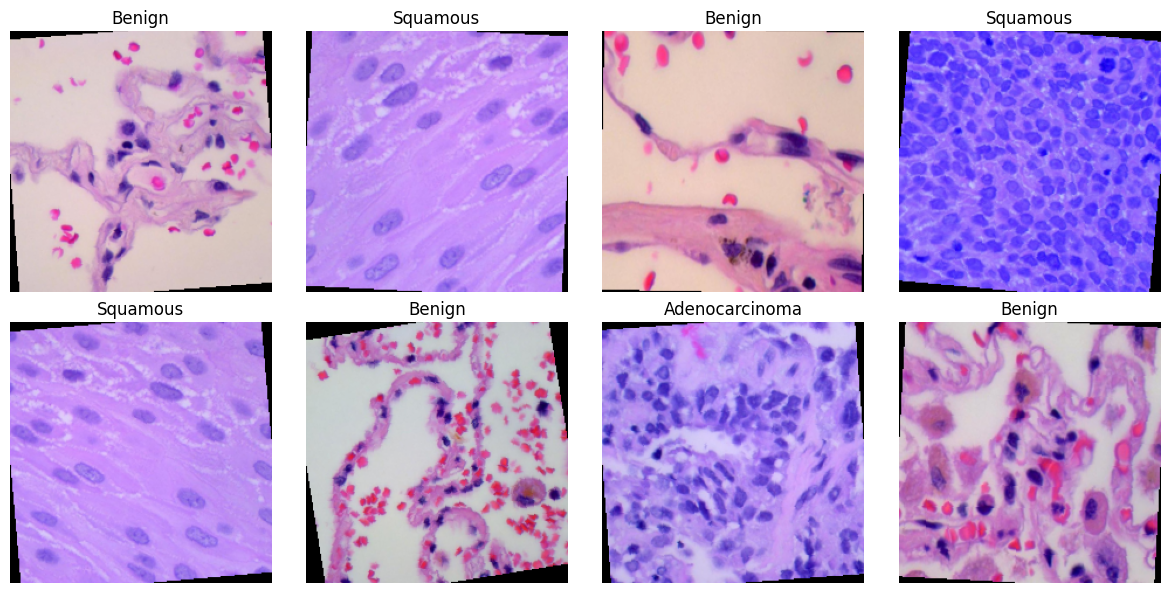

In [14]:
import matplotlib.pyplot as plt

class_names = {
    0: "Adenocarcinoma",
    1: "Benign",
    2: "Squamous"
}

fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i, ax in enumerate(axes.flatten()):

    img = images[i].permute(1,2,0).numpy()

    img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img = np.clip(img,0,1)

    ax.imshow(img)
    ax.set_title(class_names[int(labels[i])])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = torch.mean(x, dim=1, keepdim=True)

        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x_cat = torch.cat([avg_out, max_out], dim=1)

        attention = self.sigmoid(self.conv(x_cat))

        return x * attention

In [18]:
class ConvNeXtSwinSpatialFusion(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # ---------------- ConvNeXt Tiny ----------------
        self.convnext = timm.create_model(
            "convnext_tiny",
            pretrained=True,
            num_classes=0,
            global_pool=""
        )

        # ---------------- Swin Tiny ----------------
        self.swin = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0,
            global_pool=""
        )

        # Feature Alignment
        self.conv_align = nn.Linear(768, 768)
        self.swin_align = nn.Linear(768, 768)

        # Spatial Attention
        self.spatial_attention = SpatialAttention(kernel_size=7)

        # Pooling
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Dropout
        self.dropout = nn.Dropout(0.3)

        # Classifier
        self.classifier = nn.Linear(1536, num_classes)

    def forward(self, x):

        # ---------------- ConvNeXt Features ----------------
        conv_feat = self.convnext.forward_features(x)
        # B,C,H,W

        # ---------------- Swin Features ----------------
        swin_feat = self.swin.forward_features(x)
        # B,H,W,C

        # Convert Swin to B,C,H,W
        swin_feat = swin_feat.permute(0, 3, 1, 2)

        # -------- Feature Alignment --------

        B, C, H, W = conv_feat.shape
        conv_flat = conv_feat.permute(0, 2, 3, 1).reshape(-1, C)
        conv_flat = self.conv_align(conv_flat)
        conv_feat = conv_flat.reshape(B, H, W, 768).permute(0, 3, 1, 2)

        B, C, H, W = swin_feat.shape
        swin_flat = swin_feat.permute(0, 2, 3, 1).reshape(-1, C)
        swin_flat = self.swin_align(swin_flat)
        swin_feat = swin_flat.reshape(B, H, W, 768).permute(0, 3, 1, 2)

        # -------- Concatenate Features --------
        fused = torch.cat([conv_feat, swin_feat], dim=1)

        # -------- Spatial Attention --------
        fused = self.spatial_attention(fused)

        # -------- Global Pool --------
        fused = self.pool(fused)
        fused = fused.flatten(1)

        # -------- Classification --------
        fused = self.dropout(fused)
        out = self.classifier(fused)

        return out

In [19]:
model = ConvNeXtSwinSpatialFusion(num_classes=3).to(device)

print(model)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

ConvNeXtSwinSpatialFusion(
  (convnext): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=96, out_features=384, bias=True)
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Linear(in_features=384, out_features=96, bias=True)
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
           

In [20]:
criterion = nn.CrossEntropyLoss()

In [21]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [22]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [23]:
class EarlyStopping:

    def __init__(self, patience=5, min_delta=0):

        self.patience = patience
        self.min_delta = min_delta

        self.counter = 0
        self.best_loss = float("inf")
        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.stop = True

In [24]:
early_stop = EarlyStopping(patience=5)

In [25]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader, leave=False)

    for images, labels in loop:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        loop.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*correct/total:.2f}"
        )

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [26]:
from sklearn.metrics import accuracy_score

def validate(model, loader):

    model.eval()

    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader)

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    return avg_loss, accuracy

In [27]:
torch.backends.cudnn.benchmark = True

In [28]:
scaler = torch.amp.GradScaler("cuda")

In [29]:
NUM_EPOCHS = 10

best_acc = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("=" * 60)
print("Training Started")
print("=" * 60)

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc*100:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc*100:.2f}%")

    print(f"LR         : {optimizer.param_groups[0]['lr']:.8f}")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_channel_attention.pth"
        )

        print("✅ Best Model Saved")

    early_stop(val_loss)

    if early_stop.stop:

        print("\nEarly Stopping Triggered")

        break

print("\nTraining Finished")

Training Started

Epoch 1/10


  0%|          | 0/375 [00:00<?, ?it/s]

Train Loss : 0.1034
Train Acc  : 96.39%
Val Loss   : 0.0300
Val Acc    : 99.17%
LR         : 0.00009755
✅ Best Model Saved

Epoch 2/10


  0%|          | 0/375 [00:00<?, ?it/s]

Train Loss : 0.0364
Train Acc  : 98.75%
Val Loss   : 0.0166
Val Acc    : 99.70%
LR         : 0.00009045
✅ Best Model Saved

Epoch 3/10


...

Train Loss : 0.0006
Train Acc  : 99.98%
Val Loss   : 0.0018
Val Acc    : 99.93%
LR         : 0.00000955

Epoch 9/10


  0%|          | 0/375 [00:00<?, ?it/s]

Train Loss : 0.0003
Train Acc  : 99.99%
Val Loss   : 0.0017
Val Acc    : 99.93%
LR         : 0.00000245

Epoch 10/10


  0%|          | 0/375 [00:00<?, ?it/s]

Train Loss : 0.0003
Train Acc  : 99.98%
Val Loss   : 0.0016
Val Acc    : 99.93%
LR         : 0.00000000

Training Finished


In [30]:
torch.save(
    model.state_dict(),
    "best_spatial_attention.pth"
)

In [31]:
print("\nLoading Best Model...\n")

best_model = ConvNeXtSwinSpatialFusion(
    num_classes=3
).to(device)

best_model.load_state_dict(
    torch.load(
        "best_spatial_attention.pth",
        map_location=device
    )
)

best_model.eval()

test_loss, test_acc = validate(
    best_model,
    val_loader
)

print(f"\nBest Validation Accuracy : {test_acc*100:.2f}%")


Loading Best Model...


Best Validation Accuracy : 99.93%


In [32]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score,
    roc_auc_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [33]:
def evaluate_model(model, loader):

    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    print("="*60)
    print("Evaluation Metrics")
    print("="*60)

    print(f"Accuracy          : {accuracy_score(all_labels, all_preds):.4f}")
    print(f"Balanced Accuracy : {balanced_accuracy_score(all_labels, all_preds):.4f}")
    print(f"Precision         : {precision_score(all_labels, all_preds, average='weighted'):.4f}")
    print(f"Recall            : {recall_score(all_labels, all_preds, average='weighted'):.4f}")
    print(f"F1 Score          : {f1_score(all_labels, all_preds, average='weighted'):.4f}")
    print(f"MCC               : {matthews_corrcoef(all_labels, all_preds):.4f}")
    print(f"Cohen Kappa       : {cohen_kappa_score(all_labels, all_preds):.4f}")

    try:
        auc = roc_auc_score(
            all_labels,
            all_probs,
            multi_class='ovr',
            average='weighted'
        )
        print(f"ROC-AUC           : {auc:.4f}")
    except:
        print("ROC-AUC could not be computed.")

    print("\nClassification Report\n")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Adenocarcinoma",
            "Benign",
            "Squamous"
        ]
    ))

    return all_labels, all_preds, all_probs

In [34]:
labels, preds, probs = evaluate_model(
    best_model,
    val_loader
)

Evaluation Metrics
Accuracy          : 0.9993
Balanced Accuracy : 0.9993
Precision         : 0.9993
Recall            : 0.9993
F1 Score          : 0.9993
MCC               : 0.9990
Cohen Kappa       : 0.9990
ROC-AUC           : 1.0000

Classification Report

                precision    recall  f1-score   support

Adenocarcinoma       1.00      1.00      1.00      1000
        Benign       1.00      1.00      1.00      1000
      Squamous       1.00      1.00      1.00      1000

      accuracy                           1.00      3000
     macro avg       1.00      1.00      1.00      3000
  weighted avg       1.00      1.00      1.00      3000



In [35]:
external_root = "/kaggle/input/lunghist700"

In [36]:
from torchvision import datasets
from torch.utils.data import DataLoader

In [37]:
import torchvision.transforms as transforms

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [38]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/abdullahhasansajjad
/kaggle/input/datasets/abdullahhasansajjad/lunghist700
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/ssc
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/nor
/kaggle/input/datasets/rm1000
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/benign
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/adenocarcinoma


In [39]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [40]:
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [41]:
external_root = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

external_dataset = datasets.ImageFolder(
    root=external_root,
    transform=val_transform
)

print("Classes:", external_dataset.classes)
print("Class Mapping:", external_dataset.class_to_idx)
print("Total Images:", len(external_dataset))

Classes: ['aca', 'nor', 'ssc']
Class Mapping: {'aca': 0, 'nor': 1, 'ssc': 2}
Total Images: 691


In [42]:
external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [43]:
external_labels, external_preds, external_probs = evaluate_model(
    best_model,
    external_loader
)

Evaluation Metrics
Accuracy          : 0.5369
Balanced Accuracy : 0.4981
Precision         : 0.6079
Recall            : 0.5369
F1 Score          : 0.4983
MCC               : 0.3108
Cohen Kappa       : 0.2625
ROC-AUC           : 0.7282

Classification Report

                precision    recall  f1-score   support

Adenocarcinoma       0.65      0.35      0.46       280
        Benign       0.74      0.23      0.35       151
      Squamous       0.48      0.92      0.63       260

      accuracy                           0.54       691
     macro avg       0.63      0.50      0.48       691
  weighted avg       0.61      0.54      0.50       691



In [ ]:
cm = confusion_matrix(external_labels, external_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["ACA","NOR","SSC"],
    yticklabels=["ACA","NOR","SSC"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("External Validation - LungHist700")

plt.show()